In [166]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
import umap
import pandas as pd
import re
import pathlib as Path
from Bio.PDB.MMCIFParser import MMCIFParser
import numpy as np

## Creating UMAP 2D embedding of RMSD Matrix

In [ ]:
# Update to path of result .csv file
df = pd.read_csv("output/Pro1843/Pro1843_all.csv", index_col=0)

# The number of clusters
num_clusters = 4

protein_name = re.sub(r"\_.*", "", str(df.index[0]))
df.head()

,pro1843_af3_seed-1_sample-0,pro1843_af3_seed-1_sample-1,pro1843_af3_seed-1_sample-2,pro1843_af3_seed-1_sample-3,pro1843_af3_seed-1_sample-4,pro1843_af3_seed-2_sample-0,pro1843_af3_seed-2_sample-1,pro1843_af3_seed-2_sample-2,pro1843_af3_seed-2_sample-3,pro1843_af3_seed-2_sample-4,...,pro1843_chai1_seed-3_sample-0,pro1843_chai1_seed-3_sample-1,pro1843_chai1_seed-3_sample-2,pro1843_chai1_seed-3_sample-3,pro1843_chai1_seed-3_sample-4,pro1843_chai1_seed-4_sample-0,pro1843_chai1_seed-4_sample-1,pro1843_chai1_seed-4_sample-2,pro1843_chai1_seed-4_sample-3,pro1843_chai1_seed-4_sample-4
pro1843_af3_seed-1_sample-0,0.000000,2.871884,4.244609,1.684754,1.838401,10.839627,12.044267,10.721778,10.578175,10.516068,...,10.445251,7.718412,10.711608,9.698128,9.147867,7.060464,10.054837,7.650589,8.496279,8.153755
pro1843_af3_seed-1_sample-1,2.871884,0.000000,3.221407,1.782932,2.641766,10.857963,11.896425,10.656678,10.198663,10.249859,...,9.138953,7.422982,10.099392,9.357910,8.946325,7.171089,9.677995,7.500857,8.121494,7.878193
pro1843_af3_seed-1_sample-2,4.244609,3.221407,0.000000,3.556173,4.199552,10.131311,11.005361,9.583036,8.931514,9.401471,...,7.787124,5.920509,8.437148,7.854805,6.743273,5.511755,8.259787,5.790575,6.262526,6.629775
pro1843_af3_seed-1_sample-3,1.684754,1.782932,3.556173,0.000000,1.143567,10.566808,11.700751,10.413776,10.098000,10.094505,...,9.963738,7.213372,10.204209,9.194916,8.440891,6.414025,9.616969,7.169944,7.932883,7.660097
pro1843_af3_seed-1_sample-4,1.838401,2.641766,4.199552,1.143567,0.000000,11.093183,12.263108,10.952005,10.763752,10.708177,...,10.593743,7.774304,10.759238,9.715543,8.993326,6.909747,10.180715,7.768098,8.489471,8.235047


In [168]:
umap_model = umap.UMAP(n_components=2, init='random')
projections = umap_model.fit_transform(df)
df_umap = pd.DataFrame(projections, columns=['UMAP_1', 'UMAP_2'], index=df.index)

model_type = {}
for samplename in df.columns:
    match = re.search(r"af3|boltz2|chai1", samplename)
    if match:
        model_type[samplename] = match.group()

df_umap["model"] = df_umap.index.map(model_type)

/tmp/ipykernel_217752/182649421.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", len(clusters))


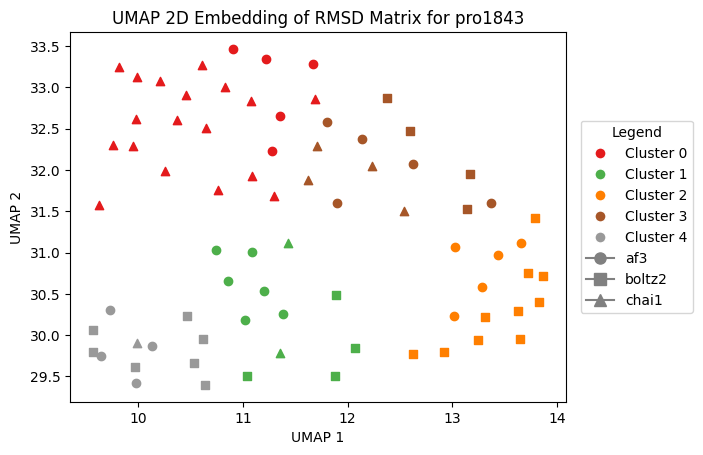

In [ ]:
marker_mapping = {
    "af3": "o",
    "boltz2": "s",
    "chai1": "^"
}

kmeans = KMeans(n_clusters=num_clusters, random_state=44)
df_umap["cluster"] = kmeans.fit_predict(df_umap[["UMAP_1", "UMAP_2"]])

clusters = df_umap["cluster"].unique()
cmap = plt.cm.get_cmap("Set1", len(clusters))

fig, ax = plt.subplots()
for model, marker in marker_mapping.items():
    for cluster in clusters:
        subset = df_umap[(df_umap["model"] == model) & (df_umap["cluster"] == cluster)]
        ax.scatter(
            subset["UMAP_1"],
            subset["UMAP_2"],
            color=cmap(cluster),
            marker=marker,
            label=f"Cluster {cluster}" if model == list(marker_mapping.keys())[0] else "",
)

cluster_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=cmap(c), 
                   markersize=8, label=f"Cluster {c}") for c in sorted(clusters)]
model_handles = [Line2D([0], [0], marker=m, color="gray", 
                 markersize=8, label=mod) for mod, m in marker_mapping.items()]

ax.legend(handles=cluster_handles + model_handles, title="Legend", loc='center right', bbox_to_anchor=(1.27, 0.5))
ax.set_title(f"UMAP 2D Embedding of RMSD Matrix for {protein_name}")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.show()

## Creating Heatmap of RMSD Matrix

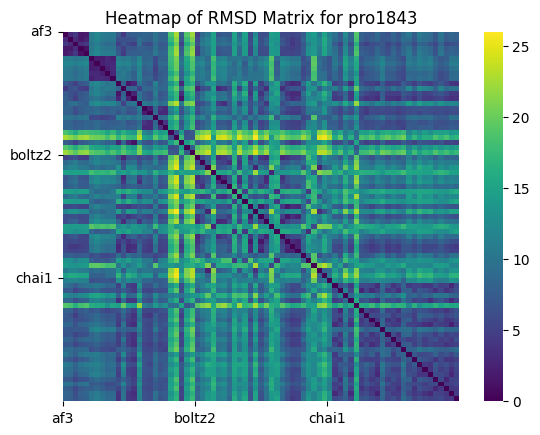

In [170]:
plt.close()

labels = df_umap["model"].unique()
# need to adjust locations if running a specific model rmsd matrix result
locations = [0, 25, 50]

fig, ax = plt.subplots()
ax = sns.heatmap(df, cmap='viridis', ax=ax)
ax.set_yticks(locations)
ax.set_yticklabels(labels)
ax.set_xticks(locations)
ax.set_xticklabels(labels, rotation=0)
ax.set_title(f"Heatmap of RMSD Matrix for {protein_name}")
plt.show()

In [171]:
df_umap.head()

,UMAP_1,UMAP_2,model,cluster
pro1843_af3_seed-1_sample-0,13.438978,30.965754,af3,2
pro1843_af3_seed-1_sample-1,13.370380,31.598566,af3,3
pro1843_af3_seed-1_sample-2,12.621099,32.077652,af3,3
pro1843_af3_seed-1_sample-3,13.026649,31.062485,af3,2
pro1843_af3_seed-1_sample-4,13.661811,31.120586,af3,2


## Creating Residue vs pLDDT plot for each cluster

In [172]:
# Update the directory to the directory of the RMSD matrix generation step
directory_path = Path.Path("structures_cif/Pro1843_wo_MBP-ligand_CYN/all")

# Update to the pLDDT threshold used in RMSD matrix generation step
threshold = 40

# Update if you change the amount of files per cluster
files_per_cluster = 3

In [173]:
parser = MMCIFParser()

def get_structure(path) -> 'Bio.PDB.Structure':
    with open(path, "r") as f:
        structure = parser.get_structure("Clottein", f)
    return structure
    
def get_plddt(structure: 'Bio.PDB.Structure') -> np.ndarray:
    residue_plddt = []

    for models in structure:
        for chains in models:
            for residue in chains:
                    if residue.get_id()[0] != " ":
                        continue
                    if "CA" in residue:
                        ca = residue["CA"]
                        plddt = ca.get_bfactor()
                        residue_plddt.append(plddt)
    residue_plddt_array = np.array(residue_plddt)
    return residue_plddt_array

df_pLDDT = pd.DataFrame(columns=["pLDDT_array", "Cluster"])

for name, row in df_umap.iterrows():
    fullpath = directory_path.joinpath(f"{name}.cif")
    if fullpath.is_file():
        structure = get_structure(fullpath)
        residue_plddt_array = get_plddt(structure)
        df_pLDDT.loc[name] = pd.Series({
            "pLDDT_array": residue_plddt_array,
            "Cluster": row["cluster"]
        })
df_pLDDT.head()

,pLDDT_array,Cluster
pro1843_af3_seed-1_sample-0,"[39.51, 32.3, 29.3, 24.16, 20.17, 21.62, 21.17...",2
pro1843_af3_seed-1_sample-1,"[30.76, 26.21, 24.7, 19.58, 15.63, 17.85, 17.1...",3
pro1843_af3_seed-1_sample-2,"[38.54, 31.46, 28.85, 23.87, 19.8, 21.97, 21.2...",3
pro1843_af3_seed-1_sample-3,"[38.04, 31.36, 28.83, 22.86, 19.14, 19.7, 19.8...",2
pro1843_af3_seed-1_sample-4,"[34.93, 28.81, 26.79, 21.25, 17.56, 19.35, 18....",2


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


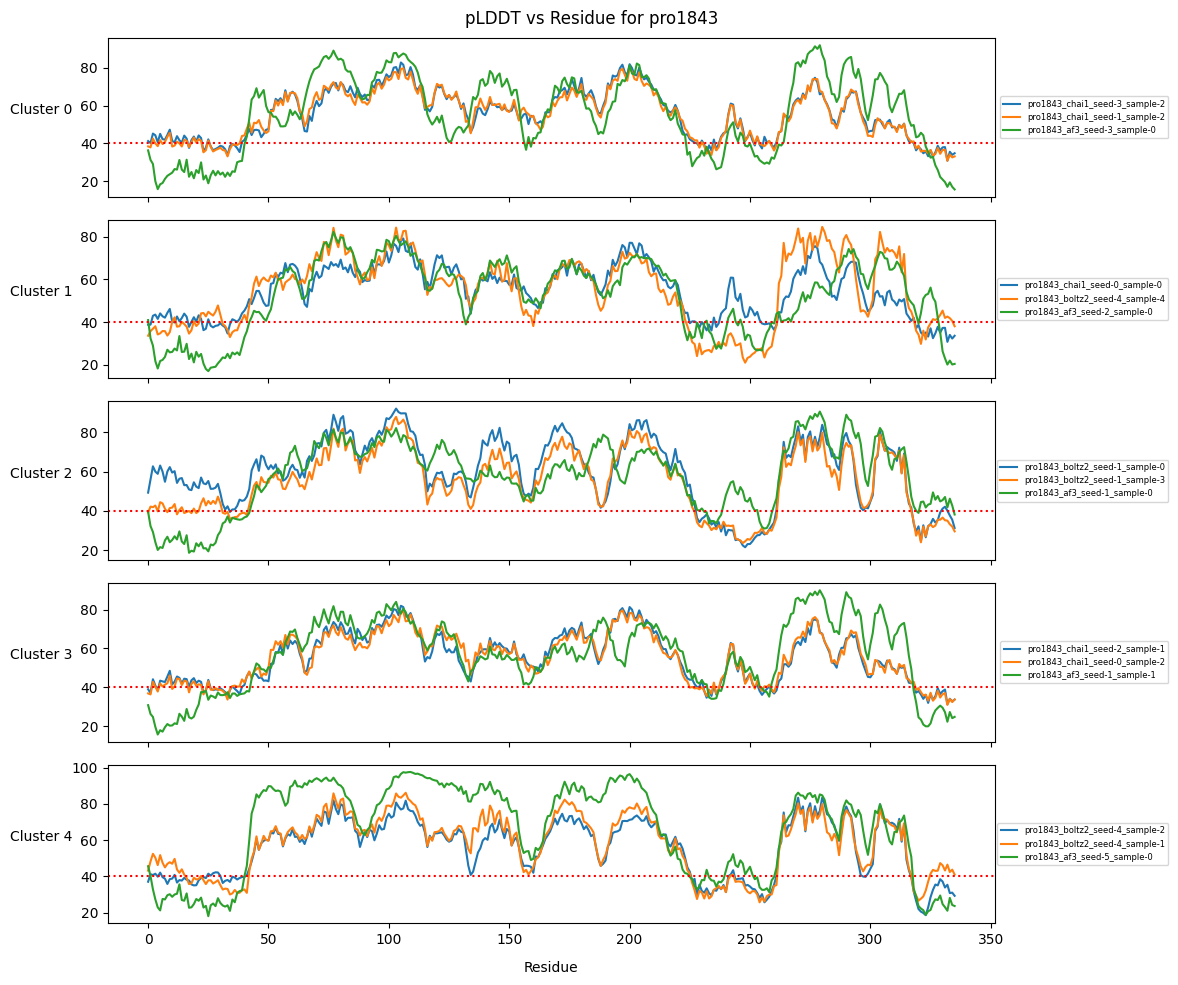

In [187]:
plt.close()
clusters = sorted(df_pLDDT["Cluster"].unique())
fig, axes = plt.subplots(len(clusters), 1, figsize=(12, 10), sharex=True)

if len(clusters) == 1:
    axes = [axes]

for ax, cluster in zip(axes, clusters):
    cluster_df = df_pLDDT[df_pLDDT["Cluster"] == cluster].sample(n=files_per_cluster, random_state=42)
    colors = plt.cm.tab10(np.linspace(0, 0.2, len(cluster_df)))
    
    for (name, row), color in zip(cluster_df.iterrows(), colors):
        ax.plot(row["pLDDT_array"], color=color, label=name)
    
    ax.axhline(y=threshold, color='red', linestyle='dotted')
    ax.set_ylabel(f"Cluster {cluster}", rotation=0)
    ax.yaxis.set_label_coords(-0.075, 0.5)
    ax.legend(loc="center right", fontsize=6, bbox_to_anchor=(1.2, 0.5))

fig.suptitle(f"pLDDT vs Residue for {protein_name}")
plt.xlabel("Residue", labelpad=10)
plt.tight_layout()
plt.show()